preprocessing


In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\HP\Desktop\ai_job_dataset.csv")

In [3]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,18-10-2024,07-11-2024,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,20-11-2024,11-01-2025,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,18-03-2025,07-04-2025,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,23-12-2024,24-02-2025,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,15-04-2025,23-06-2025,1989,6.6,Advanced Robotics


In [4]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [5]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [6]:
newdf=df[['job_title', 'salary_usd','company_location','required_skills',
       'education_required', 'years_experience', 'industry','company_name']]

In [7]:
newdf.drop_duplicates

<bound method DataFrame.drop_duplicates of                          job_title  salary_usd company_location  \
0            AI Research Scientist       90376            China   
1             AI Software Engineer       61895           Canada   
2                    AI Specialist      152626      Switzerland   
3                     NLP Engineer       80215            India   
4                    AI Consultant       54624           France   
...                            ...         ...              ...   
14995            Robotics Engineer       38604          Finland   
14996  Machine Learning Researcher       57811   United Kingdom   
14997                 NLP Engineer      189490      South Korea   
14998                   Head of AI       79461      Netherlands   
14999     Computer Vision Engineer       56481          Austria   

                                       required_skills education_required  \
0             Tableau, PyTorch, Kubernetes, Linux, NLP           Bachelor  

In [8]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MultiLabelBinarizer


<BarContainer object of 15000 artists>

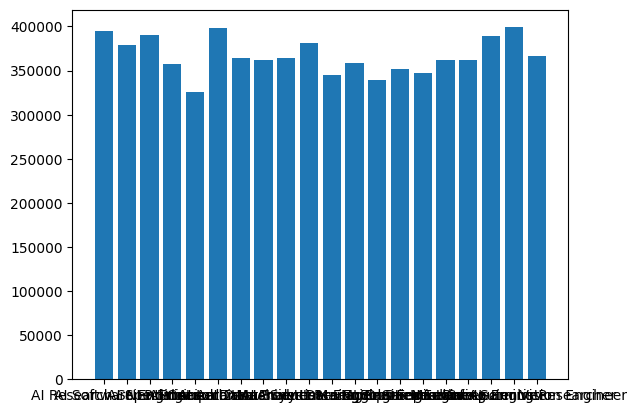

In [9]:
plt.bar(newdf['job_title'],newdf['salary_usd'],linewidth=25)



EDA

In [10]:
df.tail()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,06-02-2025,25-03-2025,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,16-10-2024,30-10-2024,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,19-03-2024,02-05-2024,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,22-03-2024,23-04-2024,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,18-07-2024,10-08-2024,2492,7.6,AI Innovations


In [11]:
df['required_skills']=df['required_skills'].apply(lambda x: [s.strip().lower() for s in x.split(',')])

In [12]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"[tableau, pytorch, kubernetes, linux, nlp]",Bachelor,9,Automotive,18-10-2024,07-11-2024,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"[deep learning, aws, mathematics, python, docker]",Master,1,Media,20-11-2024,11-01-2025,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"[kubernetes, deep learning, java, hadoop, nlp]",Associate,2,Education,18-03-2025,07-04-2025,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"[scala, sql, linux, python]",PhD,7,Consulting,23-12-2024,24-02-2025,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"[mlops, java, tableau, python]",Master,0,Media,15-04-2025,23-06-2025,1989,6.6,Advanced Robotics


In [15]:
mlb=MultiLabelBinarizer()
skill_encoded=mlb.fit_transform(df['required_skills'])

In [17]:
skill_df=pd.DataFrame(skill_encoded, columns=mlb.classes_)

In [21]:
scaler=StandardScaler()
df['salary_usd']=scaler.fit_transform(df[['salary_usd']])

In [27]:
encoder=OneHotEncoder(sparse_output=False)
job_encoded = encoder.fit_transform(df[['job_title']])
job_df = pd.DataFrame(job_encoded, columns=encoder.get_feature_names_out(['job_title']))


In [50]:
le=LabelEncoder()
edu_encoded = le.fit_transform(df[['education_required']].values)
edu_encoded = edu_encoded.reshape(-1,1)
edu_df = pd.DataFrame(edu_encoded, columns=['education_required'])

c:\Users\HP\Documents\GitHub\Career_recommendation_accurate\venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [51]:
final_df = pd.concat([df, skill_df,edu_df,job_df], axis=1)

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
import numpy as np
X = np.hstack([skill_encoded, edu_encoded])
y = df["job_title"].values

In [53]:
model = RandomForestClassifier()
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
new_skills = [["python", "sql", "excel"]]
new_edu = ["Bachelor"]

X_new = np.hstack([
    mlb.transform(new_skills),
    le.transform(new_edu).reshape(-1,1)
])

print(model.predict(X_new))

['Autonomous Systems Engineer']


c:\Users\HP\Documents\GitHub\Career_recommendation_accurate\venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['excel'] will be ignored
  warnings.warn(


In [58]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(mlb, "mlb.pkl")
joblib.dump(le, "le.pkl")

['le.pkl']